In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 172.95 GB
Available RAM: 169.88 GB


In [ ]:
# install requirements for v6 Tpu
!pip install opencv-python
!pip install tensorflow
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 115.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 11.5 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GRU, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# Global Constants
NUM_FRAMES = 40 #120                 # Sequential frames per video
MIN_FRAMES = 120                # Minimum frames required
max_frames = 120                # Maximum frames extracted
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224


In [ ]:
# GOOGLE DRIVE SETUP
from google.colab import drive
drive.mount('drive')

zip_folder = 'drive/My Drive/Colab Notebooks_videoAnalytics/all_phs1_phs6lv1_lv38_vids.zip'
extract_path = ''

with zipfile.ZipFile(zip_folder, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Mounted at drive
Extraction complete.


In [ ]:
# checking contents
!ls all_phs1_phs6lv1_lv38_vids/

larvae_temp,24_4°C,15-10-2024,12-26-27PM.mp4
larvae_temp,24_4°C,15-10-2024,12-27-37PM.mp4
larvae_temp,24_4°C,15-10-2024,12-27-45PM.mp4
larvae_temp,24_5°C,15-10-2024,12-25-56PM.mp4
larvae_temp,24_5°C,15-10-2024,12-26-51PM.mp4
larvae_temp,24_5°C,15-10-2024,12-26-58PM.mp4
larvae_temp,24_5°C,15-10-2024,12-27-14PM.mp4
larvae_temp,24_5°C,15-10-2024,12-27-29PM.mp4
larvae_temp,24_5°C,15-10-2024,12-28-00PM.mp4
larvae_temp,24_6°C,14-10-2024,03-03-25PM.mp4
larvae_temp,24_6°C,14-10-2024,03-05-37PM.mp4
larvae_temp,24_6°C,14-10-2024,04-31-17PM.mp4
larvae_temp,24_6°C,15-10-2024,12-26-43PM.mp4
larvae_temp,24_6°C,15-10-2024,12-28-08PM.mp4
larvae_temp,24_6°C,15-10-2024,12-35-58PM.mp4
larvae_temp,24_6°C,15-10-2024,12-36-05PM.mp4
larvae_temp,24_7°C,14-10-2024,03-03-49PM.mp4
larvae_temp,24_7°C,14-10-2024,03-04-12PM.mp4
larvae_temp,24_7°C,14-10-2024,03-05-30PM.mp4
larvae_temp,24_7°C,14-10-2024,04-28-44PM.mp4
larvae_temp,24_7°C,14-10-2024,04-29-13PM.mp4
larvae_temp,24_7°C,14-10-2024,04-29-52PM.mp4
larvae_tem

In [ ]:
video_count = len(os.listdir('all_phs1_phs6lv1_lv38_vids'))
print(f"Number of videos in the folder: {video_count}")

Number of videos in the folder: 1351


In [ ]:
# import metadata
metadata_file = pd.read_excel('all_phs1_phs6lv1_lv38_vids_meta_data.xlsx')
metadata_file
metadata_file.shape

(1351, 3)

In [ ]:
# FRAME PREPROCESSING
def preprocess_frame(frame, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    """
    Center crop, resize, and normalize a frame for model input.
    """
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    cropped_frame = frame[start_y:start_y + min_dim, start_x:start_x + min_dim]

    frame_resized = cv2.resize(cropped_frame, target_size)

    # NORMALIZATION FOR Xception
    frame_resized = frame_resized.astype("float32")
    frame_resized = frame_resized / 127.5 - 1

    return frame_resized

In [ ]:
def extract_all_frames(video_path, max_frames):
    """
    Extracts up to `max_frames` sequential frames from a video.
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame = preprocess_frame(frame)
        frames.append(frame)
        frame_count += 1

    cap.release()

    frames_array = np.array(frames)
    print(f"Extracted {len(frames_array)} frames from {video_path}. Target: {max_frames}")
    return frames_array


In [ ]:
def load_video_data(data_path, metadata_file, num_frames=NUM_FRAMES):
    """
    Loads and processes videos into ML samples.
    """
    metadata = pd.read_excel(metadata_file)
    X, y = [], []
    skipped_videos = []

    for _, row in metadata.iterrows():
        video_name = row['video_name']
        video_path = os.path.join(data_path, video_name)

        try:
            all_frames = extract_all_frames(video_path, num_frames)

            if all_frames is None or len(all_frames) < num_frames:
                skipped_videos.append((video_name, "insufficient frames"))
                continue

            X.append(all_frames)

            label = 1 if row['tag'].strip().lower() == 'positive' else 0
            y.append(label)

        except Exception as e:
            skipped_videos.append((video_name, f"exception: {str(e)}"))

    print("\nSkipped videos summary:")
    for vid, reason in skipped_videos:
        print(f"- {vid}: {reason}")

    return np.array(X), np.array(y)

In [ ]:
# === MAIN EXECUTION ===
if __name__ == "__main__":
    data_path = 'all_phs1_phs6lv1_lv38_vids'
    metadata_file = 'all_phs1_phs6lv1_lv38_vids_meta_data.xlsx'

    print("Loading and preprocessing video data...")
    X, y = load_video_data(data_path, metadata_file)

    print("Shape of X after loading and normalization:", X.shape)
    print("Shape of y after loading:", y.shape)

    print("Saving preprocessed arrays...")
    np.save('X_prep_40_frames.npy', X)
    np.save('y_labels_40_frames.npy', y)

    print("Feature shape:", X.shape)
    print("Label shape:", y.shape)

Loading and preprocessing video data...
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_0°C,14-10-2024,02-32-12PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_1°C,14-10-2024,02-32-21PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_0°C,14-10-2024,02-32-29PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_0°C,14-10-2024,02-32-37PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_0°C,14-10-2024,02-32-44PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_1°C,14-10-2024,02-32-52PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,24_9°C,14-10-2024,02-33-00PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,25_0°C,14-10-2024,02-33-08PM.mp4. Target: 40
Extracted 40 frames from all_phs1_phs6lv1_lv38_vids/larvae_temp,24_8°C,14-10-2024,02-33-

In [ ]:
print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)

Features (X) shape: (1351, 40, 224, 224, 3)
Labels (y) shape: (1351,)


In [ ]:
print(X)
print(y)

[[[[[0.33333337 0.33333337 0.33333337]
    [0.3411765  0.3411765  0.3411765 ]
    [0.33333337 0.33333337 0.33333337]
    ...
    [0.38823533 0.36470592 0.38823533]
    [0.35686278 0.37254906 0.38823533]
    [0.35686278 0.37254906 0.38823533]]

   [[0.3411765  0.3411765  0.3411765 ]
    [0.3411765  0.3411765  0.3411765 ]
    [0.34901965 0.34901965 0.34901965]
    ...
    [0.38823533 0.38823533 0.4039216 ]
    [0.3803922  0.39607847 0.4039216 ]
    [0.35686278 0.37254906 0.38823533]]

   [[0.33333337 0.32549024 0.3411765 ]
    [0.3411765  0.33333337 0.34901965]
    [0.3411765  0.33333337 0.34901965]
    ...
    [0.37254906 0.39607847 0.39607847]
    [0.37254906 0.39607847 0.39607847]
    [0.36470592 0.38823533 0.38823533]]

   ...

   [[0.1686275  0.13725495 0.15294123]
    [0.16078436 0.12941182 0.15294123]
    [0.1686275  0.12941182 0.15294123]
    ...
    [0.2313726  0.24705887 0.28627455]
    [0.23921573 0.24705887 0.28627455]
    [0.22352946 0.2313726  0.27058828]]

   [[0.13725495 

In [ ]:
# LOAD DATA
X = np.load('X_prep_40_frames.npy')
print("Shape of X_prep:", X.shape)

y = np.load('y_labels_40_frames.npy')
print("Shape of y_labels:", y.shape)


Shape of X_prep: (1351, 40, 224, 224, 3)
Shape of y_labels: (1351,)


In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from tensorflow.keras.utils import to_categorical

# TRAIN-VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (945, 40, 224, 224, 3)
X_val shape: (406, 40, 224, 224, 3)


In [ ]:
# ONE-HOT ENCODING
num_classes = 2
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh   = to_categorical(y_val, num_classes=num_classes)

# FEATURE EXTRACTION
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

global_avg_layer = GlobalAveragePooling2D()
feature_extractor = Model(inputs=base_model.input, outputs=global_avg_layer(base_model.output))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
import tensorflow as tf
# GRU-BASED MODEL DEFINITION
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dropout, Dense
from tensorflow.keras.models import Model

# Define input layer for video sequences (NUM_FRAMES, HEIGHT, WIDTH, 3)
input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

# Extract frame-wise features using CNN (Xception) applied to each frame
x_ception_td = TimeDistributed(feature_extractor)(input_layer)

# First GRU layer with 1024 units, returning sequences
gru_1 = GRU(1024, return_sequences=True)(x_ception_td)
dropout_1 = Dropout(0.5)(gru_1)

# Second GRU layer with 512 units
gru_2 = GRU(512)(dropout_1)
dropout_2 = Dropout(0.5)(gru_2)

# SINGLE DENSE LAYER (128 UNITS)-Fully connected dense layer
dense_1 = Dense(128, activation="relu")(dropout_2)
dropout_3 = Dropout(0.5)(dense_1)

# Output layer for binary classification-one-hot  (2 neurons + sigmoid)
output_layer = Dense(num_classes, activation="sigmoid")(dropout_3)

# Define/Build the model
model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# COMPILE
optimizer = Nadam(learning_rate=1e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 40, 2048)       │    20,861,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 40, 1024)       │     9,443,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 512)            │     2,362,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,733,098 (124.87 MB)

 Trainable params: 32,678,570 (124.66 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
# EARLY STOPPING
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

In [ ]:
# CLASS WEIGHTS
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
w0, w1 = class_weights

In [ ]:
# CALCULATE CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
w0 = class_weights[0]
w1 = class_weights[1]

In [ ]:
# TRAIN
history = model.fit(
    X_train,
    y_train_oh,
    epochs=10,
    batch_size=3,
    class_weight={0: w0, 1: w1},
    callbacks=[early_stopping],
    validation_data=(X_val, y_val_oh)
)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1290s 4s/step - accuracy: 0.5810 - loss: 0.6565 - val_accuracy: 0.7143 - val_loss: 0.6056
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.7725 - loss: 0.5073 - val_accuracy: 0.7931 - val_loss: 0.6471
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.8571 - loss: 0.3487 - val_accuracy: 0.8005 - val_loss: 0.4406
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.8804 - loss: 0.2783 - val_accuracy: 0.7857 - val_loss: 0.5477
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1083s 3s/step - accuracy: 0.9132 - loss: 0.2258 - val_accuracy: 0.8596 - val_loss: 0.4414
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1084s 3s/step - accuracy: 0.9513 - loss: 0.1349 - val_accuracy: 0.8128 - val_loss: 0.5157
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1086s 3s/step - accuracy: 0.9418 - loss: 0.1723 - val_accuracy: 0.8177 - val_loss: 0.6035
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.9577 - loss: 0.1291 - 

In [ ]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(X_val, y_val_oh)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.8596 - loss: 0.3913
Validation Loss: 0.3913
Validation Accuracy: 0.8596


In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_val)

# Convert softmax probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 124s 8s/step
Confusion Matrix:
 [[175  28]
 [ 29 174]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       203
           1       0.86      0.86      0.86       203

    accuracy                           0.86       406
   macro avg       0.86      0.86      0.86       406
weighted avg       0.86      0.86      0.86       406



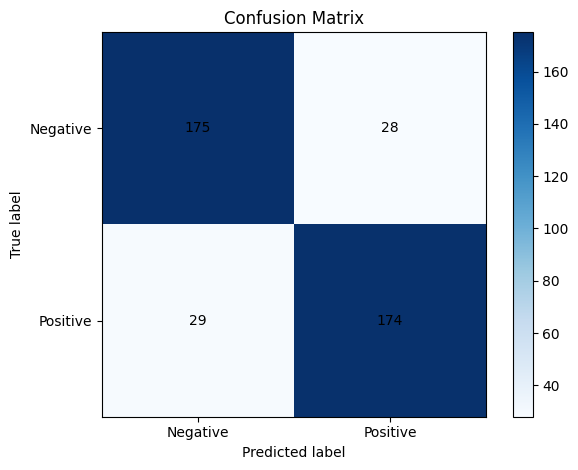

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
ticks = np.arange(2)
plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(f"confusion_matrix_40_frames.png", dpi=300, bbox_inches='tight') #save figure
plt.show()

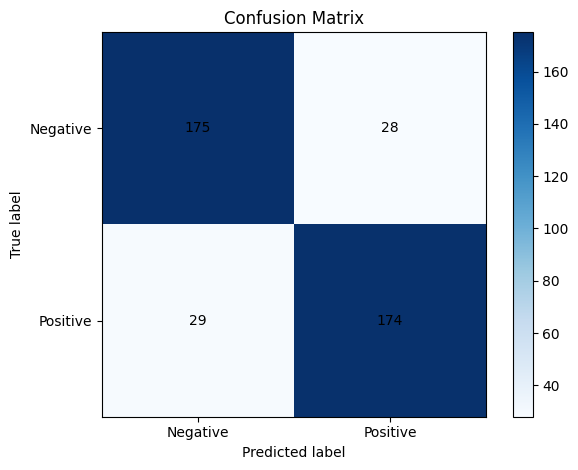

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
ticks = np.arange(2)
plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(f"confusion_matrix_40_frames.png", dpi=300, bbox_inches='tight') #save figure
plt.show()

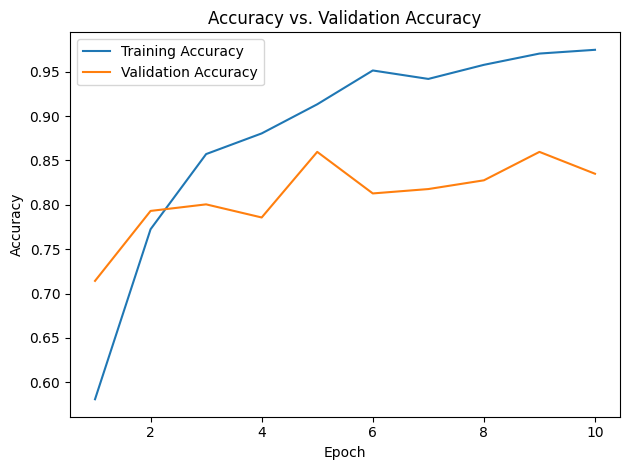

In [ ]:
# ACCURACY VS VALIDATION ACCURACY
accuracy     = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs       = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"accuracy_plot_40_frames.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

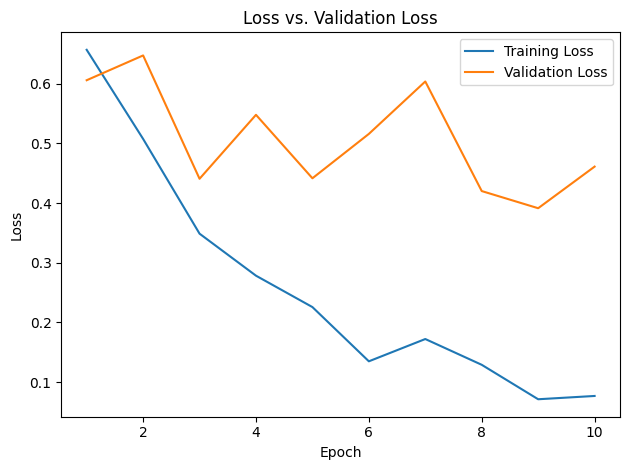

In [ ]:
# LOSS VS VALIDATION LOSS
loss      = history.history['loss']
val_loss  = history.history['val_loss']

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f"loss_plot_40_frames.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

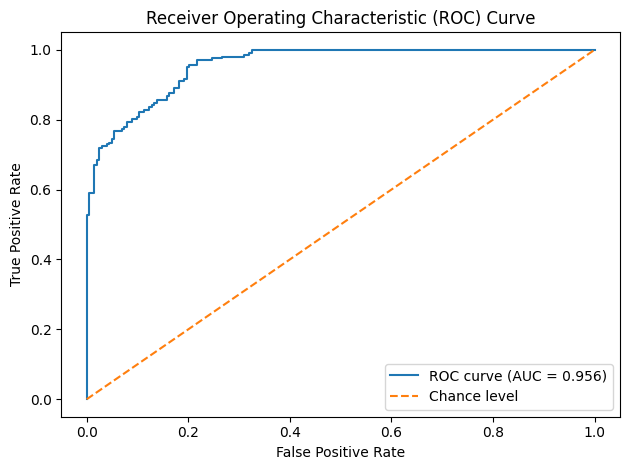

In [ ]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc

# Compute ROC curve for positive class
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"roc_curve_120_frames.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

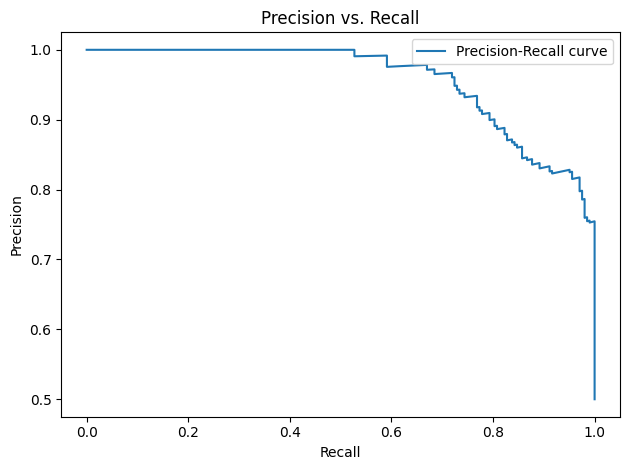

In [ ]:
# PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_prob[:,1])

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall')
plt.legend()
plt.tight_layout()
#plt.savefig(f"precision_recall_curve_segments_60.png") ##save figure
plt.savefig(f"precision_recall_curve_40_frames.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

In [ ]:
# EXPERIMENT RESULTS TABLE FOR CURRENT SEGMENT CONFIGURATION #updatel
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate evaluation metrics
precision_val = precision_score(y_true, y_pred)
recall_val = recall_score(y_true, y_pred)
f1_val = f1_score(y_true, y_pred)
accuracy_val = accuracy_score(y_true, y_pred)

# Create results table
results_table = pd.DataFrame({
    "Segments": [NUM_FRAMES],
    "Accuracy": [accuracy_val],
    #"Validation Accuracy": [accuracy],
    #"Validation Loss": [loss],
    "Precision": [precision_val],
    "Recall": [recall_val],
    "F1 Score": [f1_val],
    "ROC AUC": [roc_auc]
})

# Display table
print(f"\nExperiment Results Table: {NUM_FRAMES} Segments")
display(results_table)


Experiment Results Table: 40 Segments


,Segments,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,40,0.859606,0.861386,0.857143,0.859259,0.955762


In [ ]:
# SAVE MODEL & WEIGHTS
model.save("Xception_model_seq_40_frames.keras")
print("Model saved!")
model.save("Xception_model_seq_40_frames.h5")
print("Model saved successfully!")
model.save_weights("Xception_model_seq_40_frames.weights.h5")
print("Model weights saved!")

Model saved!
Model saved successfully!
Model weights saved!


In [ ]:
!cp /content/Xception_model_seq_40_frames.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/sequential_120_prep_frames_n_model_weights/"

In [ ]:
!cp /content/Xception_model_seq_40_frames.keras "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/sequential_120_prep_frames_n_model_weights/"

In [ ]:
!cp /content/Xception_model_seq_40_frames.weights.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/sequential_120_prep_frames_n_model_weights/"

In [ ]:
#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/sequential_120_prep_frames_n_model_weights/"

Xception_model_seq_40_frames.h5     Xception_model_seq_40_frames.weights.h5
Xception_model_seq_40_frames.keras
